In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [3]:
import pickle

# Load saved model
with open("../models/churn_model.pkl", "rb") as f:
    lr = pickle.load(f)

In [5]:
import pandas as pd

df = pd.read_csv("../data/processed_telco_data.csv")

X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
y_pred = lr.predict(X_test)

y_prob = lr.predict_proba(X_test)[:,1]

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[914 121]
 [161 213]]


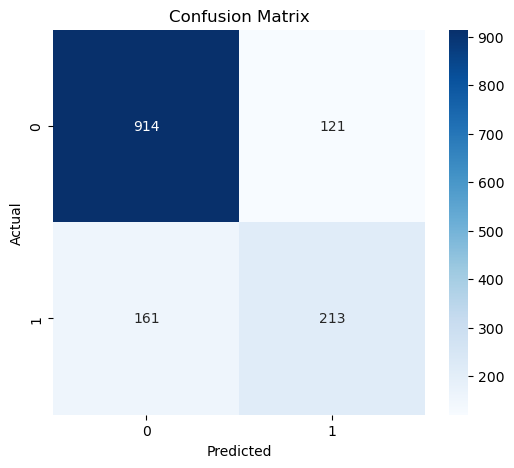

In [9]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [10]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [11]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("ROC AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7998580553584103
Precision : 0.6377245508982036
Recall : 0.56951871657754
F1 Score : 0.6016949152542372
ROC AUC : 0.8485675165982071


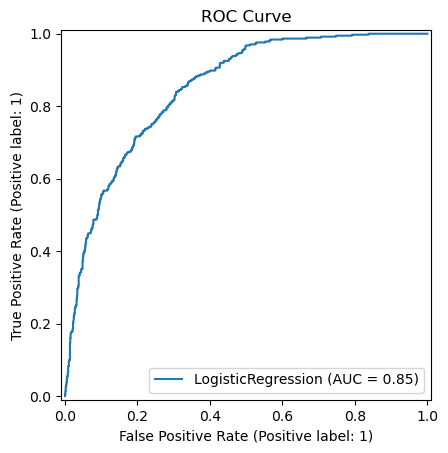

In [12]:
RocCurveDisplay.from_estimator(
    lr,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.show()

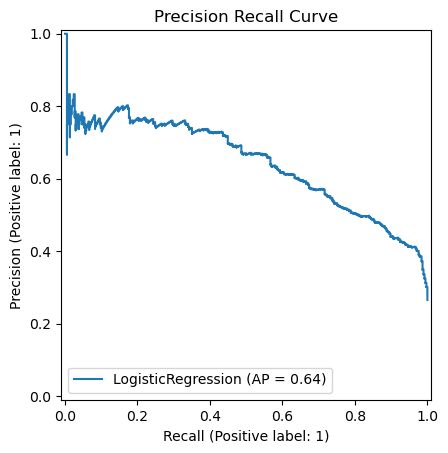

In [13]:
PrecisionRecallDisplay.from_estimator(
    lr,
    X_test,
    y_test
)

plt.title("Precision Recall Curve")

plt.show()

In [14]:
importance = pd.DataFrame({

'Feature': X.columns,

'Coefficient': lr.coef_[0]

})

importance['Absolute Value'] = abs(
    importance['Coefficient']
)

importance = importance.sort_values(
    by='Absolute Value',
    ascending=False
)

In [15]:
top10 = importance.head(10)

print(top10)

                         Feature  Coefficient  Absolute Value
0                  Tenure Months    -1.258281        1.258281
1                Monthly Charges    -0.797388        0.797388
10  Internet Service_Fiber optic     0.699324        0.699324
6                 Dependents_Yes    -0.691160        0.691160
25             Contract_Two year    -0.572569        0.572569
2                  Total Charges     0.507829        0.507829
24             Contract_One year    -0.301423        0.301423
21              Streaming TV_Yes     0.241622        0.241622
23          Streaming Movies_Yes     0.231179        0.231179
9             Multiple Lines_Yes     0.214570        0.214570


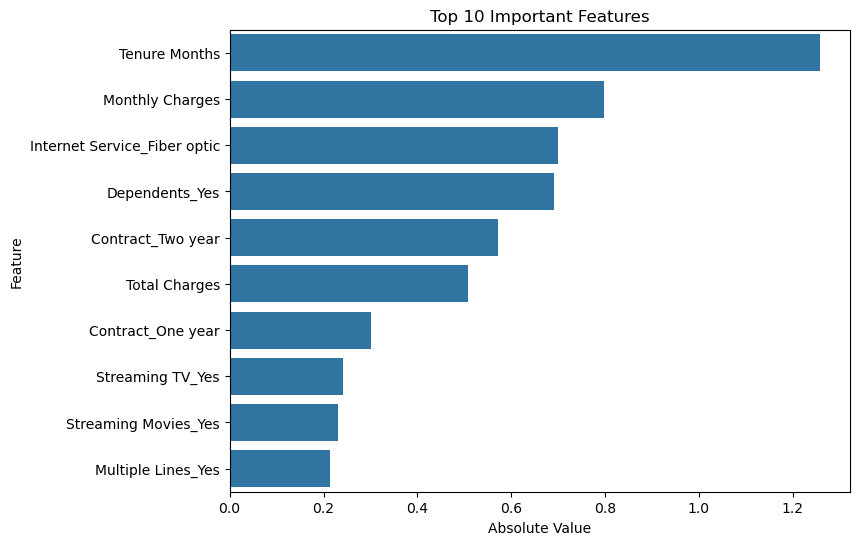

In [16]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x='Absolute Value',
    y='Feature'
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [17]:
importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [19]:
from sklearn.metrics import RocCurveDisplay

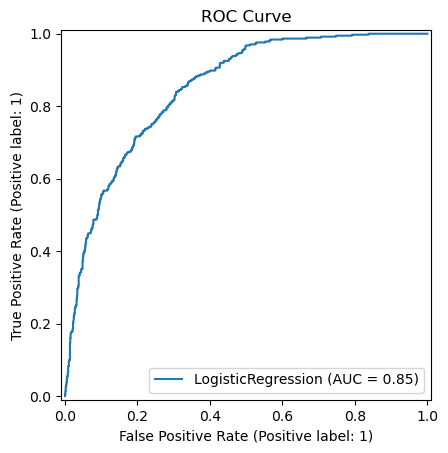

In [20]:
RocCurveDisplay.from_estimator(
    lr,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

In [21]:
from sklearn.metrics import PrecisionRecallDisplay

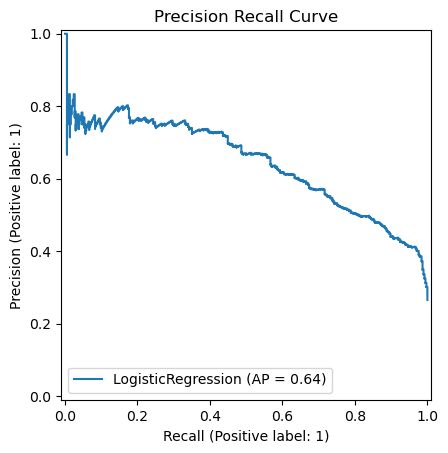

In [22]:
PrecisionRecallDisplay.from_estimator(
    lr,
    X_test,
    y_test
)

plt.title("Precision Recall Curve")
plt.show()

In [23]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient': lr.coef_[0]

})

In [24]:
importance['Absolute Value'] = abs(
    importance['Coefficient']
)

In [25]:
importance = importance.sort_values(
    by='Absolute Value',
    ascending=False
)

importance.head(10)

,Feature,Coefficient,Absolute Value
0,Tenure Months,-1.258281,1.258281
1,Monthly Charges,-0.797388,0.797388
10,Internet Service_Fiber optic,0.699324,0.699324
6,Dependents_Yes,-0.691160,0.691160
25,Contract_Two year,-0.572569,0.572569
2,Total Charges,0.507829,0.507829
24,Contract_One year,-0.301423,0.301423
21,Streaming TV_Yes,0.241622,0.241622
23,Streaming Movies_Yes,0.231179,0.231179
9,Multiple Lines_Yes,0.214570,0.214570


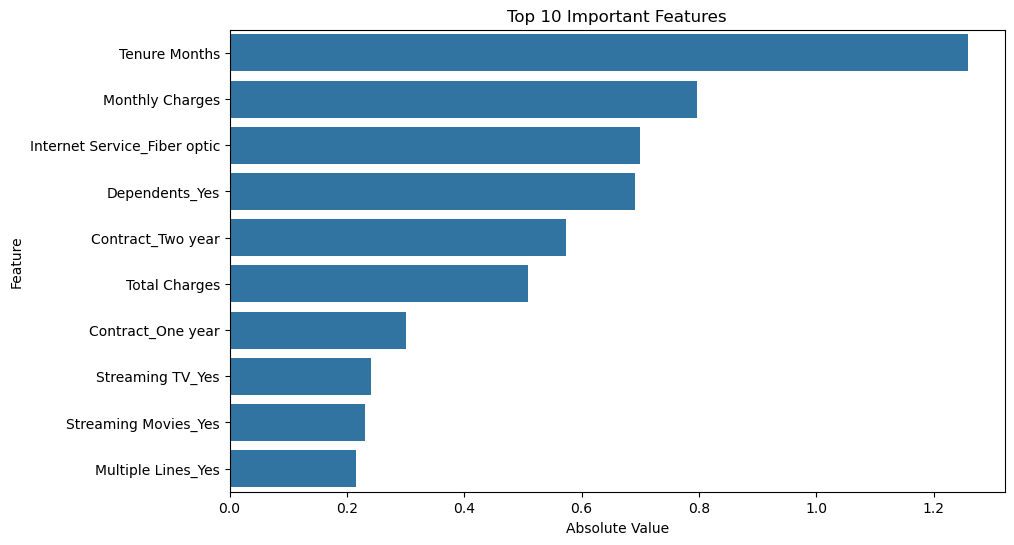

In [26]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Absolute Value',
    y='Feature'
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [27]:
importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)